In [1]:
import sys
sys.path
# sys.path.remove('PINNs-master/Utilities/')

['C:\\Users\\umroot\\anaconda3\\envs\\tf112\\python36.zip',
 'C:\\Users\\umroot\\anaconda3\\envs\\tf112\\DLLs',
 'C:\\Users\\umroot\\anaconda3\\envs\\tf112\\lib',
 'C:\\Users\\umroot\\anaconda3\\envs\\tf112',
 '',
 'C:\\Users\\umroot\\anaconda3\\envs\\tf112\\lib\\site-packages',
 'C:\\Users\\umroot\\anaconda3\\envs\\tf112\\lib\\site-packages\\win32',
 'C:\\Users\\umroot\\anaconda3\\envs\\tf112\\lib\\site-packages\\win32\\lib',
 'C:\\Users\\umroot\\anaconda3\\envs\\tf112\\lib\\site-packages\\Pythonwin',
 'C:\\Users\\umroot\\anaconda3\\envs\\tf112\\lib\\site-packages\\IPython\\extensions',
 'C:\\Users\\umroot\\.ipython']

In [2]:
sys.path.insert(0, 'PINNs-master/Utilities/')

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
from pyDOE import lhs
from plotting import newfig, savefig
from mpl_toolkits.mplot3d import Axes3D
import time
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [4]:
class PhysicsInformedNN:
    def __init__(self, X_u, u, X_f, layers, lb, ub):
        
        self.lb = lb
        self.ub = ub
        self.x_u = X_u[:,0:1]
        self.t_u = X_u[:,1:2]
        self.x_f = X_f[:,0:1]
        self.t_f = X_f[:,1:2]
        self.u = u
        self.layers = layers
        
        ######################################
        mask_x = (X_f[:, 0:1] <= 4950)
        mask_t = (X_f[:, 1:2] >= 5)
        mask = mask_x & mask_t  # boolean AND

        # space shifts (only if mask True)
        self.x_f1 = X_f[:, 0:1] + mask * 10
        self.x_f2 = X_f[:, 0:1] + mask * 20
        self.x_f3 = X_f[:, 0:1] + mask * 30
        self.x_f4 = X_f[:, 0:1] + mask * 40
        self.x_f5 = X_f[:, 0:1] + mask * 50
        
        # time shifts (only if mask True); look back in time
        self.t_f1 = X_f[:, 1:2] - mask * 1
        self.t_f2 = X_f[:, 1:2] - mask * 2
        self.t_f3 = X_f[:, 1:2] - mask * 3
        self.t_f4 = X_f[:, 1:2] - mask * 4
        self.t_f5 = X_f[:, 1:2] - mask * 5
        ######################################
        ######################################
        
        # Initialize NNs
        self.weights, self.biases = self.initialize_NN(layers)
        
        # tf placeholders and graph
        self.sess = tf.Session(config=tf.ConfigProto(allow_soft_placement=True,
                                                     log_device_placement=True))
        
        self.x_u_tf = tf.placeholder(tf.float32, shape=[None, self.x_u.shape[1]])
        self.t_u_tf = tf.placeholder(tf.float32, shape=[None, self.t_u.shape[1]])        
        self.u_tf = tf.placeholder(tf.float32, shape=[None, self.u.shape[1]])
        self.x_f_tf = tf.placeholder(tf.float32, shape=[None, self.x_f.shape[1]])
        self.t_f_tf = tf.placeholder(tf.float32, shape=[None, self.t_f.shape[1]])        
        self.u_pred = self.net_u(self.x_u_tf, self.t_u_tf) 
        
        ##########################################################################
        self.x_f1_tf = tf.placeholder(tf.float32, shape=[None, self.x_f1.shape[1]])
        self.x_f2_tf = tf.placeholder(tf.float32, shape=[None, self.x_f2.shape[1]])
        self.x_f3_tf = tf.placeholder(tf.float32, shape=[None, self.x_f3.shape[1]])
        self.x_f4_tf = tf.placeholder(tf.float32, shape=[None, self.x_f4.shape[1]])
        self.x_f5_tf = tf.placeholder(tf.float32, shape=[None, self.x_f5.shape[1]])

        self.t_f1_tf = tf.placeholder(tf.float32, shape=[None, self.t_f1.shape[1]])
        self.t_f2_tf = tf.placeholder(tf.float32, shape=[None, self.t_f2.shape[1]])
        self.t_f3_tf = tf.placeholder(tf.float32, shape=[None, self.t_f3.shape[1]])
        self.t_f4_tf = tf.placeholder(tf.float32, shape=[None, self.t_f4.shape[1]])
        self.t_f5_tf = tf.placeholder(tf.float32, shape=[None, self.t_f5.shape[1]])

        self.f_pred = self.net_f(self.x_f_tf,
                                 self.x_f1_tf, self.t_f1_tf,
                                 self.x_f2_tf, self.t_f2_tf,
                                 self.x_f3_tf, self.t_f3_tf,
                                 self.x_f4_tf, self.t_f4_tf,
                                 self.x_f5_tf, self.t_f5_tf,
                                 self.t_f_tf)
        ##########################################################################
        
        # integrate physics to deep learning, cost function
        self.loss = tf.reduce_mean(tf.square(self.u_tf - self.u_pred)) + tf.reduce_mean(tf.square(self.f_pred))

        self.optimizer = tf.contrib.opt.ScipyOptimizerInterface(self.loss, 
                                                                method = 'L-BFGS-B', 
                                                                options = {'maxiter': 50000,
                                                                           'maxfun': 50000,
                                                                           'maxcor': 50,
                                                                           'maxls': 50,
                                                                           'ftol' : 1.0 * np.finfo(float).eps})
        
        init = tf.global_variables_initializer()
        self.sess.run(init)
                
    def initialize_NN(self, layers):        
        weights = []
        biases = []
        num_layers = len(layers) 
        for l in range(0, num_layers-1):
            W = self.xavier_init(size=[layers[l], layers[l+1]])
            b = tf.Variable(tf.zeros([1,layers[l+1]], dtype=tf.float32), dtype=tf.float32)
            weights.append(W)
            biases.append(b)        
        return weights, biases
        
    def xavier_init(self, size):
        in_dim = size[0]
        out_dim = size[1]        
        xavier_stddev = np.sqrt(2/(in_dim + out_dim))
        ##################### Addition ##############################
        return tf.Variable(tf.truncated_normal([in_dim, out_dim], stddev=xavier_stddev, seed=se), dtype=tf.float32)
        #############################################################
    
    def neural_net(self, X, weights, biases):
        num_layers = len(weights) + 1
        H = 2.0*(X - self.lb)/(self.ub - self.lb) - 1.0
        for l in range(0,num_layers-2):
            W = weights[l]
            b = biases[l]
            H = tf.tanh(tf.add(tf.matmul(H, W), b))
        W = weights[-1]
        b = biases[-1]
        Y = tf.add(tf.matmul(H, W), b)
        return Y
            
    def net_u(self, x, t):
        u = self.neural_net(tf.concat([x,t],1), self.weights, self.biases)
#         u = tf.clip_by_value(u, clip_value_min=0, clip_value_max=0.1)
        return u
    
    ##################################
    def net_f(self, x,
              x1, t1,
              x2, t2,
              x3, t3,
              x4, t4,
              x5, t5,
              t):
    
        u  = self.net_u(x,  t)
        u1 = self.net_u(x1, t1)
        u2 = self.net_u(x2, t2)
        u3 = self.net_u(x3, t3)
        u4 = self.net_u(x4, t4)
        u5 = self.net_u(x5, t5)
        
        ud = (1 * u + 1 * u1 + 1 * u2 + 1 * u3 + 1 * u4 + u5) / 6
        
        u_t = tf.gradients(u, t)[0]
        u_x = tf.gradients(u, x)[0]
        ud_x = tf.gradients(ud, x)[0]
        
        f = u_t + 25 * u_x - (25 / 0.05) * (u * ud_x + ud * u_x)
        return f * 10

    
    def callback(self, loss):
        print('Loss:', loss)
        
    def train(self):     
        #################################################
        tf_dict = {
            self.x_u_tf: self.x_u, self.t_u_tf: self.t_u, self.u_tf: self.u,
            self.x_f_tf: self.x_f, self.t_f_tf: self.t_f,
            self.x_f1_tf: self.x_f1, self.x_f2_tf: self.x_f2, self.x_f3_tf: self.x_f3,
            self.x_f4_tf: self.x_f4, self.x_f5_tf: self.x_f5,
            self.t_f1_tf: self.t_f1, self.t_f2_tf: self.t_f2, self.t_f3_tf: self.t_f3,
            self.t_f4_tf: self.t_f4, self.t_f5_tf: self.t_f5
        }
        #################################################                                                                                                                 
        self.optimizer.minimize(self.sess, 
                                feed_dict = tf_dict,         
                                fetches = [self.loss], 
                                loss_callback = self.callback)        
                                    
    def predict(self, X_star):       
        u_star = self.sess.run(self.u_pred, {self.x_u_tf: X_star[:,0:1], self.t_u_tf: X_star[:,1:2]})  
        # f_star = self.sess.run(self.f_pred, {self.x_f_tf: X_star[:,0:1], self.t_f_tf: X_star[:,1:2]})   
        return u_star

In [5]:
se = 1234
np.random.seed(1234)
tf.set_random_seed(1234)

N_u = 1000
N_f = 20000
layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]
# layers = [2, 50, 50, 50, 50, 50, 50, 50, 50, 50, 1]

data = scipy.io.loadmat('data-synthetic.mat')


t = data['tScale'].T.flatten()[:,None]
x = data['xScale'].T.flatten()[:,None]
Exact = np.real(data['k'])
X, T = np.meshgrid(x,t)

X_star = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))
u_star = Exact.flatten()[:,None]              
lb = X_star.min(0)
ub = X_star.max(0)     


############################### Training Data #################################
# Eulerian samples: only sample data on four designated lines (x=1000, x=3000, t=100, t=200)
x_lines = [1000.0, 3000.0]
t_lines = [100.0, 200.0]
tol = 1e-6  # tolerance for floating comparisons; increase (e.g., 1e-3) if no points match

x_vals = X_star[:, 0]
t_vals = X_star[:, 1]

mask_x = np.zeros_like(x_vals, dtype=bool)
for xv in x_lines:
    mask_x |= (np.abs(x_vals - xv) < tol)

mask_t = np.zeros_like(t_vals, dtype=bool)
for tv in t_lines:
    mask_t |= (np.abs(t_vals - tv) < tol)

mask_lines = mask_x | mask_t

X_lines = X_star[mask_lines, :]
u_lines = u_star[mask_lines, :]

if X_lines.shape[0] == 0:
    raise RuntimeError(
        "No points matched the requested lines. "
        "Your grid may not contain exactly x=1000/3000 or t=100/200. "
        "Try increasing tol (e.g., 1e-3) or choose nearest grid values."
    )

if X_lines.shape[0] < N_u:
    print(f"[warn] Only {X_lines.shape[0]} eligible points on the four lines; using all of them.")
    idx = np.arange(X_lines.shape[0])
else:
    idx = np.random.choice(X_lines.shape[0], N_u, replace=False)

X_u_train = X_lines[idx, :]
u_train = u_lines[idx, :]
# ######################### Collocation Points #################################
X_f_train = lb + (ub - lb) * lhs(2, N_f)
X_f_train = np.vstack((X_f_train, X_u_train))

C:\Users\umroot\anaconda3\envs\tf112\lib\site-packages\scipy\io\matlab\mio.py:208: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [6]:
model = PhysicsInformedNN(X_u_train, u_train, X_f_train, layers, lb, ub)

start_time = time.time()                
model.train()
elapsed = time.time() - start_time                
print('Training time: %.4f' % (elapsed))
u_pred = model.predict(X_star)
error_u = np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2)
print('Error u: %e' % (error_u))                     
U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')
Error = np.abs(Exact - U_pred)

Loss: 0.03019287
Loss: 0.11554609
Loss: 0.065464154
Loss: 0.004412168
Loss: 0.003727048
Loss: 0.00035724908
Loss: 0.00034021022
Loss: 0.0002620938
Loss: 0.00020800365
Loss: 0.00017932135
Loss: 0.00017772416
Loss: 0.00017734517
Loss: 0.00017685303
Loss: 0.00017573955
Loss: 0.00017302223
Loss: 0.00016717271
Loss: 0.00015779237
Loss: 0.00014669508
Loss: 0.00013106319
Loss: 0.000126917
Loss: 0.00012601117
Loss: 0.00012522012
Loss: 0.00012542949
Loss: 0.0001241967
Loss: 0.00012306786
Loss: 0.00012061713
Loss: 0.0001191579
Loss: 0.00011792815
Loss: 0.00011865659
Loss: 0.00011659329
Loss: 0.00011580567
Loss: 0.000115398376
Loss: 0.00011493437
Loss: 0.0001147146
Loss: 0.00011401748
Loss: 0.0001125083
Loss: 0.00010977149
Loss: 0.00011048434
Loss: 0.000108146516
Loss: 0.000104106904
Loss: 0.00010207905
Loss: 9.9679935e-05
Loss: 9.806981e-05
Loss: 9.676604e-05
Loss: 9.4694136e-05
Loss: 9.31093e-05
Loss: 9.210387e-05
Loss: 9.077262e-05
Loss: 9.019569e-05
Loss: 8.9866764e-05
Loss: 8.970254e-05
Loss

No handles with labels found to put in legend.
C:\Users\umroot\anaconda3\envs\tf112\lib\site-packages\matplotlib\font_manager.py:1333: UserWarning: findfont: Font family ['serif'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))


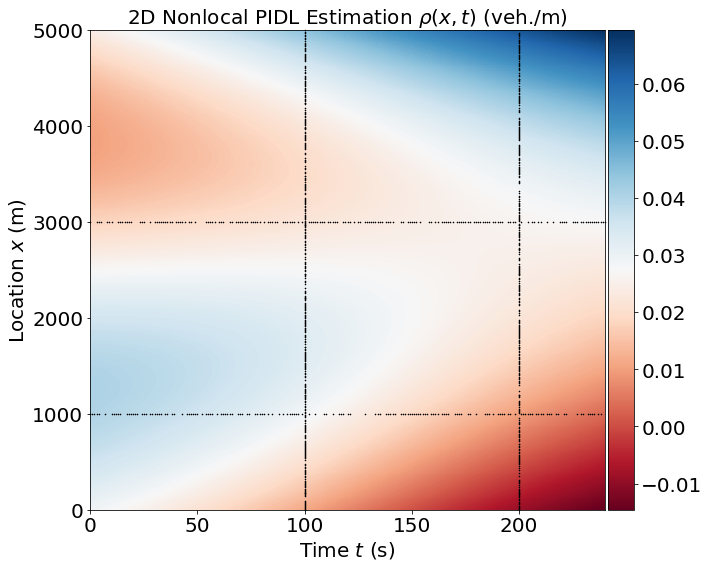

In [7]:
fig, ax = newfig(2, 1)
ax.axis('off')

####### Row 0: PIDL: u(t,x) ##################    
gs0 = gridspec.GridSpec(1, 2)
gs0.update(top=1, bottom=0, left=0.15, right=0.85, wspace=0)
ax = plt.subplot(gs0[:, :])
ax.tick_params(axis='both', which='major', labelsize=20)

h = ax.imshow(U_pred.T, interpolation='nearest', cmap='RdBu', 
              extent=[t.min(), t.max(), x.min(), x.max()], 
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cax.tick_params(labelsize=20)
fig.colorbar(h, cax=cax)

ax.plot(X_u_train[:,1], X_u_train[:,0], 'kx', markersize = 1, clip_on = False)

ax.set_xlabel('Time $t$ (s)', fontsize = 20)
ax.set_ylabel('Location $x$ (m)', fontsize = 20)
ax.legend(frameon=False, loc = 'best', fontsize = 20)
ax.set_title('2D Nonlocal PIDL Estimation $\\rho (x,t)$ (veh./m)', fontsize = 20)

savefig('figures/2d_constant_500_5s_1k_20k')